#AT1

##Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from google.colab import drive, files
drive.mount('/content/drive')
from PIL import Image
import os
from IPython.display import display
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Flatten, concatenate, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import array_to_img
from sklearn.preprocessing import LabelBinarizer, StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision
from tensorflow.keras.metrics import Recall
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from IPython.display import FileLink
import pickle
from tensorflow.keras.callbacks import ReduceLROnPlateau

Mounted at /content/drive


##Import df

In [2]:
df = pd.read_csv('/content/drive/My Drive/Data Science/Master of Data Science and Innovation/MDSI-3S - iLab Capstone Project/Skin_Cancer_MNIST_HAM10000/HAM10000_metadata.csv')

df

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


##Encode Attributes

In [3]:
# Crear una copia del DataFrame original
df_codificado = df[["dx", "image_id", "dx_type", "age", "sex", "localization"]].copy(deep=True)

# Identificar las columnas categóricas y numéricas
categorical_columns = ["sex", "localization"]
other_columns = ["dx", "image_id", "age"]

# Crear un objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' para evitar la multicolinealidad (opcional)

# Ajustar y transformar solo las columnas categóricas
encoded_data = encoder.fit_transform(df_codificado[categorical_columns])

# Convertir el array codificado en un DataFrame con nombres de columnas
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))

# Combinar las columnas codificadas con las columnas numéricas originales
df_codificado = pd.concat([df_codificado[other_columns], encoded_df], axis=1)

##Changing Target Variable into binary variable

In [4]:
df_codificado['dx'] = df_codificado['dx'].apply(lambda x: 1 if x == 'mel' else 0)

## Split data

In [5]:
X_train, X_val, y_train, y_val = train_test_split(df_codificado.drop("dx", axis=1), df_codificado["dx"], test_size=0.2, random_state=43)

## Undersampling

In [6]:
# Apply SMOTE to oversample the minority class in the training set
undersampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)

# Convert the resampled data back to DataFrames
X_train_undersampled = pd.DataFrame(X_train_undersampled, columns=X_train.columns)
y_train_undersampled = pd.Series(y_train_undersampled)

print(y_train_undersampled.value_counts())

dx
0    859
1    859
Name: count, dtype: int64


##Resampling

###Resampling df_train

In [7]:
df_train_undersampled = pd.concat([X_train_undersampled, y_train_undersampled], axis=1)

df_train_sampled = df_train_undersampled.sample(n=800, random_state=42)

df_train_sampled = df_train_sampled.reset_index(drop=True)

In [8]:
df_train_sampled["dx"].value_counts()

,count
dx,
0,405
1,395


###Resampling df_val

In [9]:
df_val = pd.concat([X_val, y_val], axis=1)

df_val_sampled = df_val.sample(n=200, random_state=42)

df_val_sampled = df_val_sampled.reset_index(drop=True)

In [10]:
df_val_sampled["dx"].value_counts()

,count
dx,
0,171
1,29


##Importing images

In [11]:
train_images_list = np.array(df_train_sampled["image_id"].tolist())
val_images_list = np.array(df_val_sampled["image_id"].tolist())
total_images_list = np.concatenate((train_images_list, val_images_list))

# Define the folder path where images are stored
folder_path = '/content/drive/My Drive/Data Science/Master of Data Science and Innovation/MDSI-3S - iLab Capstone Project/Skin_Cancer_MNIST_HAM10000/HAM10000_images_part_1'

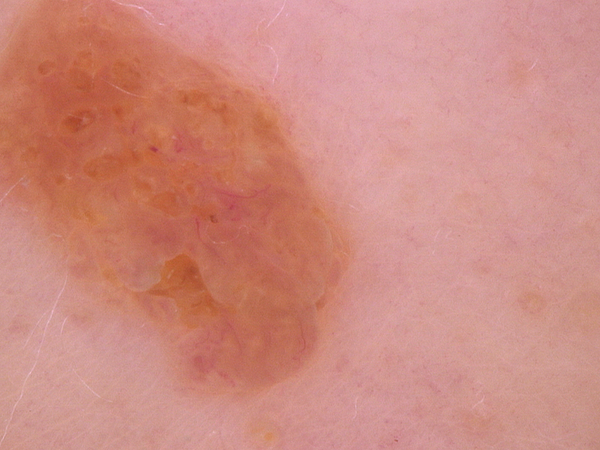

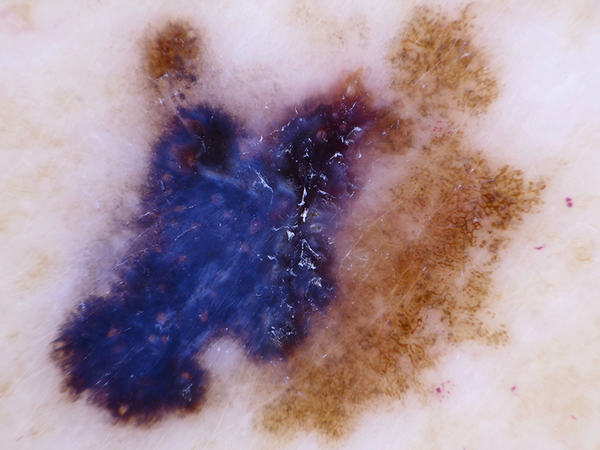

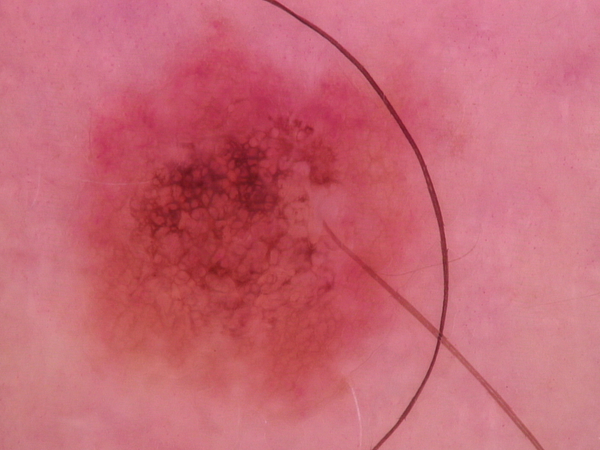

In [12]:
# Load images from the folder
images = {}
for filename in os.listdir(folder_path):
    if filename.endswith(('.jpg')):

      substr_name = filename[:-4]

      if(substr_name in total_images_list):
        img_path = os.path.join(folder_path, filename)
        images[filename.replace(".jpg", "")] = Image.open(img_path)

# Display some images
for i, (clave, valor) in enumerate(images.items()):
    if i < 3:
        display(valor)
    else:
        break

##Model Training

###Preprocessing

In [13]:
# Función para obtener datos de imagen según el nombre
def get_image_data(image_name):
    return images.get(image_name, None)

In [14]:
#Assign images to dataframe column "image_data"
df_train_sampled["image_data"] = df_train_sampled["image_id"].apply(get_image_data)
df_val_sampled["image_data"] = df_val_sampled["image_id"].apply(get_image_data)

In [15]:
#Botar rows que no tengan imágenes asociadas
df_train_sampled = df_train_sampled[df_train_sampled["image_data"].apply(lambda x: type(x) != type(None))]
df_val_sampled = df_val_sampled[df_val_sampled["image_data"].apply(lambda x: type(x) != type(None))]

#Botar columna "image_id"
df_train_sampled.drop("image_id", axis=1, inplace=True)
df_val_sampled.drop("image_id", axis=1, inplace=True)

<ipython-input-15-4ceb6da55e9a>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_sampled.drop("image_id", axis=1, inplace=True)


In [16]:
# Prepare the training and validation "dx" column
train_images = np.array(df_train_sampled['image_data'].tolist())
train_labels = np.array(df_train_sampled["dx"].tolist())
val_images = np.array(df_val_sampled['image_data'].tolist())
val_labels = np.array(df_val_sampled['dx'].tolist())

train_labels = to_categorical(train_labels, num_classes=2)
val_labels = to_categorical(val_labels, num_classes=2)
print()

##Model2

###Preprocessing

In [17]:
df_train_sampled.isna().sum()

,0
age,3
sex_male,0
sex_unknown,0
localization_acral,0
localization_back,0
localization_chest,0
localization_ear,0
localization_face,0
localization_foot,0
localization_genital,0


In [18]:
#Age column is the only column with NaN values
mean_age = df_train_sampled['age'].mean()

# Replace NaN values with the mean
df_train_sampled['age'].fillna(mean_age, inplace=True)
df_val_sampled['age'].fillna(mean_age, inplace=True)

In [19]:
X_train = df_train_sampled.drop("dx", axis=1)
X_val = df_val_sampled.drop("dx", axis=1)

In [20]:
# Extract additional data
train_additional = np.array(X_train.drop("image_data", axis=1).values)
val_additional = np.array(X_val.drop("image_data", axis=1).values)

# Normalize the additional data if needed
scaler = StandardScaler()
train_additional_norm = scaler.fit_transform(train_additional)
val_additional_norm = scaler.transform(val_additional)

In [21]:
def resize_images(images, target_size=(224, 224)):
    resized_images = []
    for image in images:
        resized_image = array_to_img(image).resize(target_size)  # Resize image to 224x224
        image_array = img_to_array(resized_image) / 255.0  # Convert back to array and normalize
        resized_images.append(image_array)
    return np.array(resized_images)

# Resize the training and validation images
resized_train_images = resize_images(train_images, target_size=(224, 224))
resized_val_images = resize_images(val_images, target_size=(224, 224))

###Model

In [33]:
# Assuming the images are 224x224 with 3 channels (RGB)
image_input_shape = (224, 224, 3)
# Assuming the attributes have been one-hot encoded or standardized and have a specific number of features
num_attributes = train_additional.shape[1]  # Number of columns in the dataframe

# Image input branch
image_input = Input(shape=image_input_shape, name='image_input')
x = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(image_input)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Flatten()(x)

# Attribute input branch
attribute_input = Input(shape=(num_attributes,), name='attribute_input')
y = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(attribute_input)  # Reduced from 32 to 16
y = Dropout(0.5)(y)  # Keeping the dropout rate

# Merge the branches
combined = concatenate([x, y])
z = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(combined)  # Reduced from 64 to 32
z = Dropout(0.5)(z)  # Keeping dropout rate to 0.5
output = Dense(2, activation='softmax')(z)  # Final output layer

# Create the model
model = Model(inputs=[image_input, attribute_input], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=["accuracy"])

# Summary of the model
model.summary()

# Create an ImageDataGenerator for augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Apply the augmentation only on the training images
train_image_gen = train_datagen.flow(resized_train_images, train_labels, batch_size=16)

# No augmentation for validation images
val_datagen = ImageDataGenerator()
val_image_gen = val_datagen.flow(resized_val_images, val_labels, batch_size=16)

def combined_generator(image_gen, attribute_data):
    while True:
        # Get the next batch from the image generator
        image_batch, label_batch = next(image_gen)
        # Slice the attribute data to match the batch size from the image generator
        attribute_batch = attribute_data[:len(image_batch)]

        # Convert all to numpy arrays and ensure correct structure
        image_batch = np.array(image_batch, dtype=np.float32)
        attribute_batch = np.array(attribute_batch, dtype=np.float32)
        label_batch = np.array(label_batch, dtype=np.float32)

        # Ensure the correct tuple format ((image_input, attribute_input), label)
        yield ((image_batch, attribute_batch), label_batch)

# Create a custom dataset from the generator
train_generator = lambda: combined_generator(train_image_gen, train_additional_norm)

# Define the output signature for TensorFlow dataset
output_signature = (
    (tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),  # Image input
     tf.TensorSpec(shape=(None, num_attributes), dtype=tf.float32)),  # Attribute input
    tf.TensorSpec(shape=(None, 2), dtype=tf.float32)  # Label output (assuming 2 classes)
)

# Create a TensorFlow dataset
train_dataset = tf.data.Dataset.from_generator(
    train_generator,
    output_signature=output_signature
)

# Define the ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Monitor validation loss
    factor=0.5,           # Reduce the learning rate by half
    patience=3,           # Number of epochs with no improvement before reducing learning rate
    min_lr=1e-6,          # Lower bound on the learning rate
    verbose=1             # Print messages when the learning rate is reduced
)

# Train the model with the callback
history = model.fit(
    train_dataset,  # Use the custom dataset
    steps_per_epoch=len(train_image_gen),  # Match steps per epoch to the image generator
    validation_data=([resized_val_images, val_additional_norm], val_labels),  # Validation data
    epochs=20,
    callbacks=[reduce_lr]  # Add the ReduceLROnPlateau callback
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 222, 222, 32)   │            896 │ image_input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 111, 111, 32)   │              0 │ conv2d_9[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 111, 111, 32)   │            128 │ max_pooling2d_9[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 109, 109, 64)   │         18,496 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_10          │ (None, 54, 54, 64)     │              0 │ conv2d_10[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 54, 54, 64)     │            256 │ max_pooling2d_10[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 52, 52, 128)    │         73,856 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_11          │ (None, 26, 26, 128)    │              0 │ conv2d_11[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attribute_input           │ (None, 17)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 26, 26, 128)    │            512 │ max_pooling2d_11[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 16)             │            288 │ attribute_input[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 86528)          │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 16)             │              0 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 86544)          │              0 │ flatten_3[0][0],       │
│ (Concatenate)             │                        │                │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)     

 Total params: 2,863,938 (10.93 MB)

 Trainable params: 2,863,490 (10.92 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6068 - loss: 5.7103 - val_accuracy: 0.6250 - val_loss: 0.9698 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6103 - loss: 3.8472 - val_accuracy: 0.4250 - val_loss: 1.6743 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6266 - loss: 2.2062 - val_accuracy: 0.1450 - val_loss: 21.7807 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6435 - loss: 6.0723
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6434 - loss: 6.0189 - val_accuracy: 0.1450 - val_loss: 3.5489 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6807 - loss: 2.3430 - val_accuracy: 0.2050 - val_loss: 1.2022 - learning_rate: 5.0000e-04
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6458 - loss: 1.4177 - val_a

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 827ms/step - accuracy: 0.6528 - loss: 0.8989
Validation Loss: 0.9107761383056641
Validation Accuracy: 0.6449999809265137


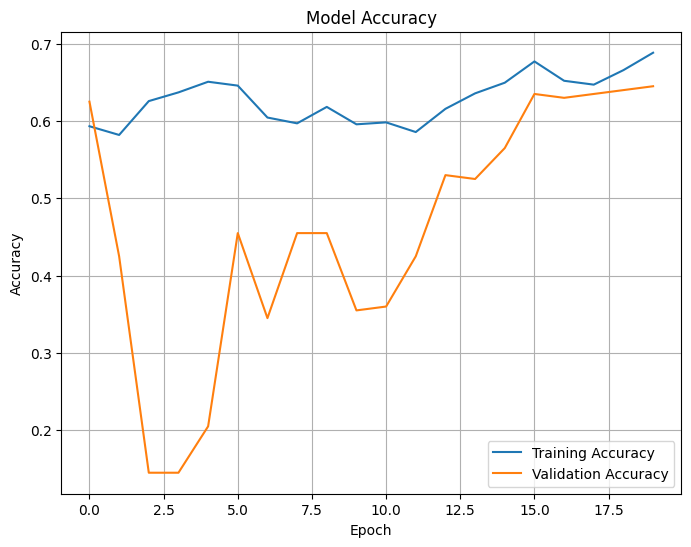

In [34]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate([resized_val_images, val_additional_norm], val_labels)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

def plot_accuracy(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Call the function to plot accuracy
plot_accuracy(history)

###Validation data

In [35]:
val_predictions = model.predict([resized_val_images, val_additional_norm])

# Convert predictions from probabilities to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# Convert one-hot encoded validation labels to class labels
val_true_labels = np.argmax(val_labels, axis=1)

# Generate the classification report
report = classification_report(val_true_labels, val_pred_labels, target_names=['class_0', 'class_1'])
print(report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
              precision    recall  f1-score   support

     class_0       0.97      0.60      0.74       171
     class_1       0.28      0.90      0.42        29

    accuracy                           0.65       200
   macro avg       0.62      0.75      0.58       200
weighted avg       0.87      0.65      0.70       200



7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step


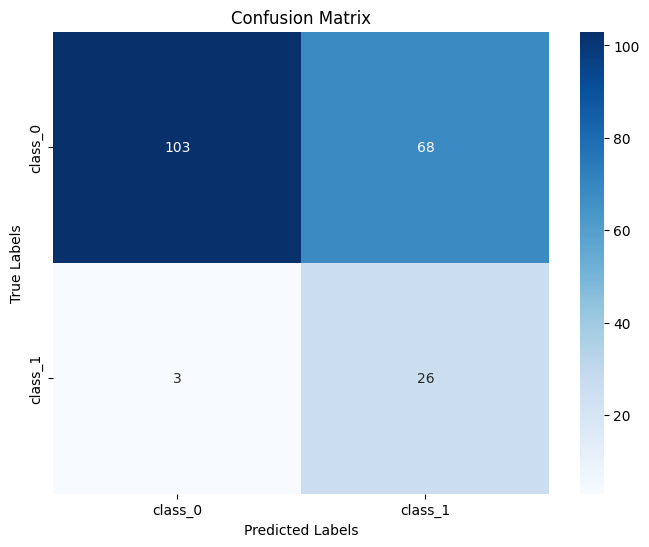

In [36]:
val_predictions = model.predict([resized_val_images, val_additional_norm])

# Convert predictions from probabilities to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# Convert one-hot encoded validation labels to class labels
val_true_labels = np.argmax(val_labels, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(val_true_labels, val_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['class_0', 'class_1'], yticklabels=['class_0', 'class_1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

###Validation data - Custom threshold

In [39]:
def apply_custom_threshold(predictions, threshold=0.6):
    """
    Apply a custom threshold to softmax predictions.
    Predictions are two-class softmax outputs, and this function will return
    the predicted class based on the given threshold.

    Args:
    predictions (np.array): Softmax outputs from the model.
    threshold (float): Threshold for classifying the positive class.

    Returns:
    np.array: Binary classification based on the threshold.
    """
    return (predictions[:, 1] >= threshold).astype(int)  # Assuming class 1 is the positive class

In [42]:
# Example of using the custom threshold after model prediction
val_predictions = model.predict([resized_val_images, val_additional_norm])

# Apply the custom threshold
custom_threshold_val_preds = apply_custom_threshold(val_predictions, threshold=0.55)

# Generate the classification report
report = classification_report(val_true_labels, custom_threshold_val_preds, target_names=['class_0', 'class_1'])
print(report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
              precision    recall  f1-score   support

     class_0       0.94      0.78      0.85       171
     class_1       0.34      0.69      0.46        29

    accuracy                           0.77       200
   macro avg       0.64      0.73      0.65       200
weighted avg       0.85      0.77      0.79       200



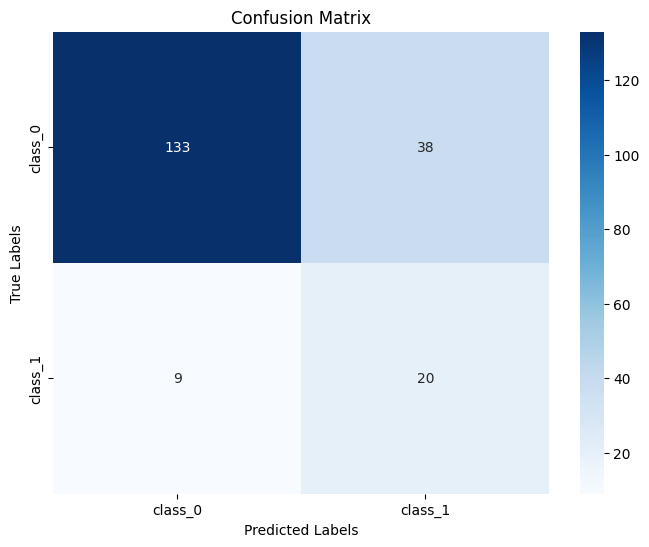

In [43]:
# Generate the confusion matrix
cm = confusion_matrix(val_true_labels, custom_threshold_val_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['class_0', 'class_1'], yticklabels=['class_0', 'class_1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Export Model

In [44]:
# Save the entire model (architecture + weights)
model.save('my_model.h5')

#Dow load
files.download('my_model.h5')

# Save the encoder to a pickle file in the current directory
encoder_pickle_file = 'one_hot_encoder.pkl'
with open(encoder_pickle_file, 'wb') as f:
    pickle.dump(encoder, f)

# Download the pickle file
files.download(encoder_pickle_file)

# Save the scaler using pickle in the current directory
scaler_pickle_file = 'standard_scaler_pickle.pkl'
with open(scaler_pickle_file, 'wb') as file:
    pickle.dump(scaler, file)

# Download the scaler pickle file
files.download(scaler_pickle_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>